# Syntax controls for concatenated Pythia representations

Compare the true syntax norm fraction against four controls for concatenated representations (`avg_tokens=0`):
- syntax-shuffle control: batch-shuffled syntax centroids
- token-shuffle control: token-shuffled syntax centroids only
- syntax+token-shuffle control: both centroid shuffles together
- word-shuffled-input control: activations from word-shuffled input sentences, evaluated against the true centroids

Important: the token-shuffle controls act on the syntax centroids only. The sentence activations are left unchanged. The word-shuffled-input control instead changes the activations and keeps the true centroids fixed.

In [30]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

models = [
    'pythia6p9b_step0',
    'pythia6p9b_step512',
    'pythia6p9b_step4000',
    'pythia6p9b_step16000',
    'pythia6p9b_step64000',
    'pythia6p9b_step143000',
]
min_token_length = 3
n_samples = 2018
global_center_flag = 1

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 15
plt.rcParams['figure.autolayout'] = True


def load_concat_run(model, activation_match_var='matching'):
    root = (
        Path('/home/acevedo/syn-sem/pythia/results')
        / f'model_{model}'
        / 'avg_tokens_0'
        / f'min_token_length_{min_token_length}'
        / f'n_samples_{n_samples}'
        / 'norms'
        / f'global_center_flag_{global_center_flag}'
    )
    if activation_match_var != 'matching':
        root = root / f'activation_match_var_{activation_match_var}'
    path = root / 'norms.npz'
    if not path.exists():
        return None
    return np.load(path)


In [31]:
checkpoint_steps = []
true_means = []
syntax_shuffle_means = []
token_shuffle_means = []
syntax_token_shuffle_means = []
word_shuffle_input_means = []

for model in models:
    run_true = load_concat_run(model)
    run_word_shuffle = load_concat_run(model, activation_match_var='matching_wordshuffled')
    if run_true is None or run_word_shuffle is None:
        print(f'skipping {model}: missing one of the norm files')
        continue
    needed_true = ['permuted_syn_means', 'shuffled_tokens_syn_means', 'combined_shuffle_syn_means']
    if any(key not in run_true.files for key in needed_true):
        print(f'skipping {model}: missing one of the centroid-side controls')
        continue

    checkpoint_steps.append(int(model.split('step')[-1]))
    true_means.append(float(np.mean(run_true['syn_means'])))
    syntax_shuffle_means.append(float(np.mean(run_true['permuted_syn_means'])))
    token_shuffle_means.append(float(np.mean(run_true['shuffled_tokens_syn_means'])))
    syntax_token_shuffle_means.append(float(np.mean(run_true['combined_shuffle_syn_means'])))
    word_shuffle_input_means.append(float(np.mean(run_word_shuffle['syn_means'])))

checkpoint_steps = np.array(checkpoint_steps)
true_means = np.array(true_means)
syntax_shuffle_means = np.array(syntax_shuffle_means)
token_shuffle_means = np.array(token_shuffle_means)
syntax_token_shuffle_means = np.array(syntax_token_shuffle_means)
word_shuffle_input_means = np.array(word_shuffle_input_means)

for step, true_mean, syn_mean, tok_mean, both_mean, word_mean in zip(
    checkpoint_steps,
    true_means,
    syntax_shuffle_means,
    token_shuffle_means,
    syntax_token_shuffle_means,
    word_shuffle_input_means,
):
    print(
        f'step={step:>6}  true={true_mean:.4f}  syntax_shuffle={syn_mean:.4f}  '
        f'token_shuffle_centroids={tok_mean:.4f}  syntax_token_shuffle={both_mean:.4f}  '
        f'word_shuffled_inputs={word_mean:.4f}'
    )


step=     0  true=0.1130  syntax_shuffle=0.0164  token_shuffle_centroids=0.0062  syntax_token_shuffle=0.0060  word_shuffled_inputs=0.0159
step=   512  true=0.3972  syntax_shuffle=0.0694  token_shuffle_centroids=0.0232  syntax_token_shuffle=0.0228  word_shuffled_inputs=0.0512
step=  4000  true=0.1840  syntax_shuffle=0.0174  token_shuffle_centroids=0.0044  syntax_token_shuffle=0.0045  word_shuffled_inputs=0.0151
step= 16000  true=0.1389  syntax_shuffle=0.0118  token_shuffle_centroids=0.0028  syntax_token_shuffle=0.0029  word_shuffled_inputs=0.0099
step= 64000  true=0.1179  syntax_shuffle=0.0098  token_shuffle_centroids=0.0023  syntax_token_shuffle=0.0023  word_shuffled_inputs=0.0081
step=143000  true=0.1223  syntax_shuffle=0.0108  token_shuffle_centroids=0.0026  syntax_token_shuffle=0.0027  word_shuffled_inputs=0.0087


PosixPath('/home/acevedo/syn-sem/pythia/results/figs/pythia6p9b_permuted_control_syn_norms_concat_n2018.pdf')

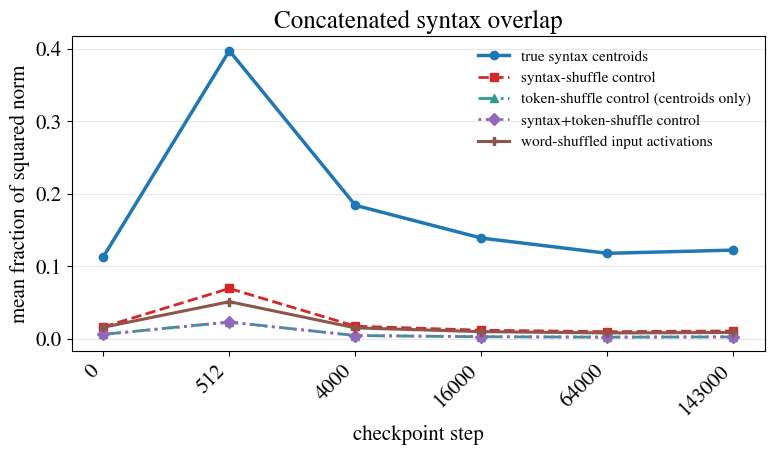

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(8.0, 4.8))

plot_x = np.arange(len(checkpoint_steps))
ax.plot(plot_x, true_means, marker='o', linewidth=2.5, color='#1f77b4', label='true syntax centroids')
ax.plot(plot_x, syntax_shuffle_means, marker='s', linewidth=2.0, linestyle='--', color='#d62728', label='syntax-shuffle control')
ax.plot(plot_x, token_shuffle_means, marker='^', linewidth=2.0, linestyle='-.', color='#2a9d8f', label='token-shuffle control (centroids only)')
ax.plot(plot_x, syntax_token_shuffle_means, marker='D', linewidth=2.0, linestyle=':', color='#9467bd', label='syntax+token-shuffle control')
ax.plot(plot_x, word_shuffle_input_means, marker='P', linewidth=2.2, color='#8c564b', label='word-shuffled input activations')
ax.set_xticks(plot_x)
ax.set_xticklabels(checkpoint_steps, rotation=45, ha='right')
ax.set_xlabel('checkpoint step')
ax.set_ylabel('mean fraction of squared norm')
ax.set_title('Concatenated syntax overlap')
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False, fontsize=11)

fig_dir = Path('/home/acevedo/syn-sem/pythia/results/figs')
fig_dir.mkdir(parents=True, exist_ok=True)
out_path = fig_dir / 'pythia6p9b_permuted_control_syn_norms_concat_n2018.pdf'
fig.savefig(out_path, bbox_inches='tight')
out_path
